In [22]:
pip install rdkit

In [23]:
# ============================================================
# 1. Instalación e importación de librerías
# ============================================================

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
from google.colab import files

In [24]:
# ============================================================
# 2. Cargar archivo CSV desde la computadora
# ============================================================
uploaded = files.upload()

# Tomar automáticamente el primer archivo cargado
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Columnas disponibles:")
print(df.columns)


Saving fragments_with_umap.csv to fragments_with_umap (3).csv
Columnas disponibles:
Index(['Identifier', 'Original_SMILES', 'Fragment_SMILES', 'Rule', 'Mode',
       'UMAP_1', 'UMAP_2'],
      dtype='object')


In [25]:
df.head()

,Identifier,Original_SMILES,Fragment_SMILES,Rule,Mode,UMAP_1,UMAP_2
0,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,4.704682,6.208411
1,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[4*]NC1CSSCC(C(=O)NC(C(=O)NCC(=O)NC(CCC[NH+]=C...,Amide,RECAP,11.168615,12.146476
2,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CCC[NH+]=C(N)N)NC(=O)CNC(=O)CNC(=O)...,Amide,RECAP,4.709050,6.204665
3,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,-4.342031,-3.659706
4,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)CNC(=O)CNC(=O)C([NH3+])CCC[NH+]=C(N)N,Amide,RECAP,4.735446,6.182208


In [26]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

# ============================================================
# 3. Funciones para calcular propiedades con RDKit
# ============================================================
def calc_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series([
            np.nan, np.nan, np.nan,
            np.nan, np.nan, np.nan,
            np.nan, np.nan
        ])

    # Peso molecular
    mw = Descriptors.MolWt(mol)

    # Número de átomos que NO son H
    non_H_atoms = sum(
        1 for atom in mol.GetAtoms()
        if atom.GetSymbol() != "H"
    )

    # Número de carbonos sp3
    sp3_carbons = sum(
        1 for atom in mol.GetAtoms()
        if atom.GetSymbol() == "C"
        and atom.GetHybridization() == Chem.rdchem.HybridizationType.SP3
    )

    # Hydrogen bond donors
    hbd = Lipinski.NumHDonors(mol)

    # Hydrogen bond acceptors
    hba = Lipinski.NumHAcceptors(mol)

    # cLogP (Wildman–Crippen)
    clogp = Descriptors.MolLogP(mol)

    # Número de enlaces rotables
    rot_bonds = Lipinski.NumRotatableBonds(mol)

    # PSA (Topological Polar Surface Area)
    psa = Descriptors.TPSA(mol)

    return pd.Series([
        mw,
        non_H_atoms,
        sp3_carbons,
        hbd,
        hba,
        clogp,
        rot_bonds,
        psa
    ])

In [27]:
# ============================================================
# 4. Cálculo de propiedades
# ============================================================
df[
    ["MW", "NonHAtoms", "C_sp3", "HBD", "HBA", "ClogP", "NRot", "PSA"]
] = df["Fragment_SMILES"].apply(calc_properties)

# Eliminar filas con SMILES inválidos
df = df.dropna(subset=["MW", "NonHAtoms", "C_sp3", "HBD", "HBA", "ClogP", "NRot", "PSA"])

df.head()


,Identifier,Original_SMILES,Fragment_SMILES,Rule,Mode,UMAP_1,UMAP_2,MW,NonHAtoms,C_sp3,HBD,HBA,ClogP,NRot,PSA
0,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,4.704682,6.208411,549.710611,39.0,15.0,11.0,5.0,-8.8107,19.0,293.13
1,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[4*]NC1CSSCC(C(=O)NC(C(=O)NCC(=O)NC(CCC[NH+]=C...,Amide,RECAP,11.168615,12.146476,1619.034000,111.0,37.0,27.0,19.0,-14.8270,30.0,688.59
2,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CCC[NH+]=C(N)N)NC(=O)CNC(=O)CNC(=O)...,Amide,RECAP,4.709050,6.204665,430.514000,31.0,10.0,10.0,4.0,-9.3416,15.0,264.03
3,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,-4.342031,-3.659706,119.196611,10.0,5.0,1.0,2.0,0.5309,4.0,29.10
4,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)CNC(=O)CNC(=O)C([NH3+])CCC[NH+]=C(N)N,Amide,RECAP,4.735446,6.182208,273.317000,20.0,6.0,6.0,3.0,-5.9606,9.0,168.92


/tmp/ipykernel_171/753847168.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: remove_outliers_iqr(x, prop))
/tmp/ipykernel_171/753847168.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: remove_outliers_iqr(x, prop))
/tmp/ipykernel_171/753847168.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

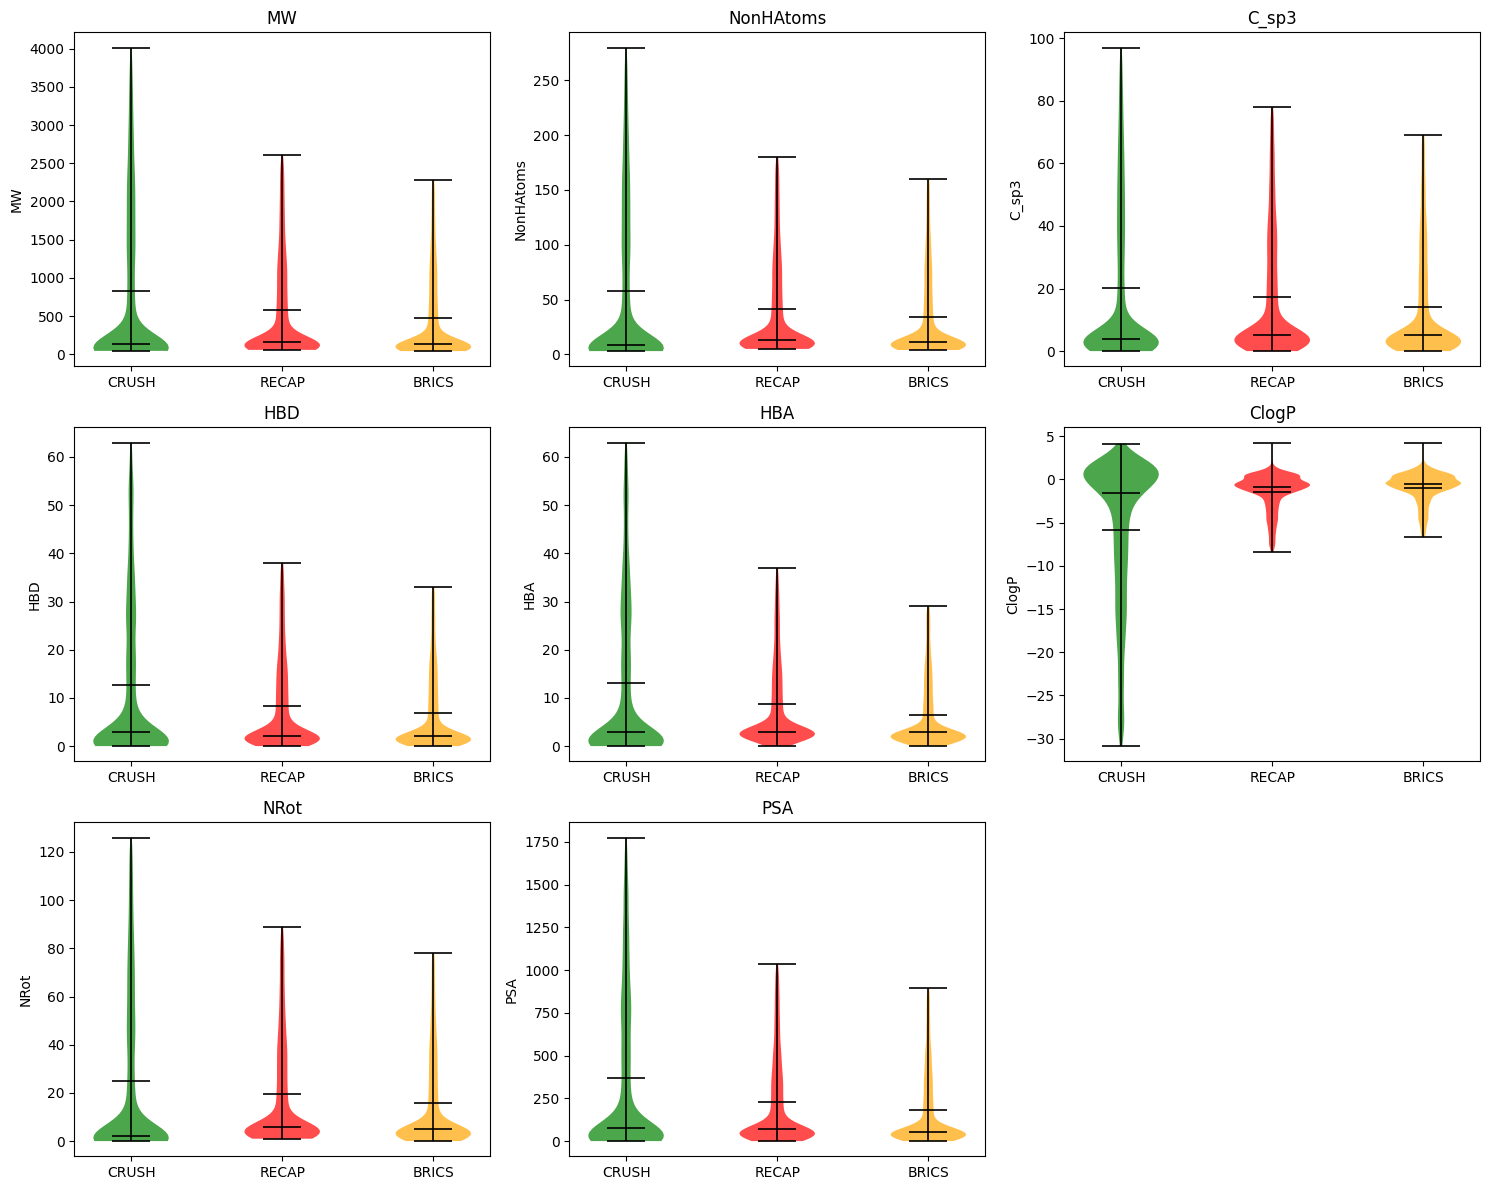

In [28]:
import matplotlib.pyplot as plt
import math

palette = {
    "CRUSH": "green",
    "RECAP": "red",
    "BRICS": "orange"
}

order = ["CRUSH", "RECAP", "BRICS"]
properties = ["MW", "NonHAtoms", "C_sp3", "HBD", "HBA", "ClogP", "NRot", "PSA"]

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# ============================================================
# Crear grilla dinámica de subplots
# ============================================================
n_props = len(properties)
n_cols = 3
n_rows = math.ceil(n_props / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=False
)

axes = axes.flatten()

# ============================================================
# Graficar cada propiedad
# ============================================================
for ax, prop in zip(axes, properties):

    # Eliminar outliers por grupo y propiedad
    df_clean = (
        df.groupby("Mode", group_keys=False)
          .apply(lambda x: remove_outliers_iqr(x, prop))
    )

    data = [df_clean[df_clean["Mode"] == m][prop] for m in order]

    parts = ax.violinplot(
        data,
        showmeans=True,
        showmedians=True
    )

    # Colorear violines
    for body, mode in zip(parts["bodies"], order):
        body.set_facecolor(palette[mode])
        body.set_alpha(0.7)

    # Líneas internas en negro
    for key in ["cmeans", "cmedians", "cbars", "cmins", "cmaxes"]:
        if key in parts:
            parts[key].set_color("black")
            parts[key].set_linewidth(1.2)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_title(prop)
    ax.set_ylabel(prop)

# ============================================================
# Apagar ejes vacíos (si sobran)
# ============================================================
for ax in axes[len(properties):]:
    ax.axis("off")

plt.tight_layout()
plt.show()